In [2]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter,zoom
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion,binary_dilation
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
import pickle
import warnings
import seaborn as sns

In [3]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')

behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=100
event='fixed_10flies_final'
ch_g=2
ch_r=1
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
os.listdir(later_dir)

['behave_dict_total_best.pkl',
 'giant_tf.npy',
 '239_tf_total.h5',
 'inc_lowest',
 '234_tf_total.h5',
 'behave_dict_total_fixed_10flies_final.pkl',
 '210_tf_total.h5',
 'behave_dict_total_10flies.pkl',
 'non_pos',
 'inc_dec',
 'behave_dict_total_first_5.pkl',
 'inc_flat',
 'behave_dict_total_subsamp_inc.pkl',
 '241_tf_total.h5',
 'behave_dict_total_fixed_best_final.pkl',
 '217_tf_total.h5',
 '226_tf_total.h5',
 'inc_inc',
 'non_non',
 'behave_dict_total_first_3.pkl',
 'dec_non',
 'lc_glom_masks',
 'behave_dict_total_flat.pkl',
 'non_neg',
 'inc_non',
 '250_tf_total.h5',
 'individual_supervox_dict.h5',
 'dec_inc',
 'flat_inc',
 'non_dec',
 'flat_flat',
 'total',
 'inc_low',
 '228_tf_total.h5',
 'flat',
 'inc',
 'behave_dict_total_prev_behavior.pkl',
 'flat_non',
 'flat_dec',
 'behave_dict_total_best_5sec.pkl',
 'figs',
 'non_flat',
 '10flies_total_dict.pkl',
 '10flies_giant_tf.npy',
 'behave_dict_total_new_best_5sec.pkl',
 'behave_dict_total_new_10flies_5sec.pkl',
 'non_move',
 '227_tf

In [5]:
total_path = os.path.join(later_dir, 'behave_dict_total_10flies.pkl')
print("Loading total dict")
with open(total_path, 'rb') as file:
        data = pickle.load(file)

Loading total dict


In [6]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [7]:
data['total'].shape

(314, 146, 91, 24)

In [8]:
behave_dict_z={}
for behavior in data:
    print(behavior)
    signals_total_z=scipy.stats.zscore(data[behavior],axis=-1)#[...,14:41]
    behave_dict_z[behavior]=signals_total_z

total
inc
dec
flat


In [9]:
behaviors=np.asarray(list(data.keys()))

In [10]:
behave_dict_z['total'].shape

(314, 146, 91, 24)

In [11]:
%%time
n_clusters=2000
supervox_dict_total=brainsss.make_supervox_dict(behave_dict_z, behaviors, n_clusters,giant_cluster_labels)


total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
CPU times: user 23 s, sys: 299 ms, total: 23.3 s
Wall time: 23.3 s


# Put the Supervoxs back into anatomical space

In [12]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
    supervox_brain=supervox_dict_total[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_brain,-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain,cluster_labels=giant_cluster_labels,n_clusters=n_clusters)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

total
(314, 146, 91, 24)
inc
(314, 146, 91, 24)
dec
(314, 146, 91, 24)
flat
(314, 146, 91, 24)
CPU times: user 48.7 s, sys: 1.36 s, total: 50 s
Wall time: 50 s


In [13]:
fixed = brainsss.load_fda_meanbrain()
brain=behave_dict_z['total']
# brain=full_res_total_clean
# smoothed=gaussian_filter(full_res['total'], sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, behave_dict['total'], np.nan)
masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

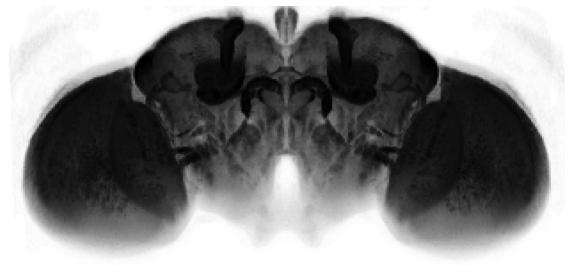

In [14]:
fig = plt.subplots(figsize=(10,10))
plt.imshow(np.max(fixed.numpy(), axis=-1).T, cmap='binary')
plt.axis('off');
# plt.savefig(os.path.join(save_dir,'fda_mean_brain.png'), dpi=300, bbox_inches='tight')

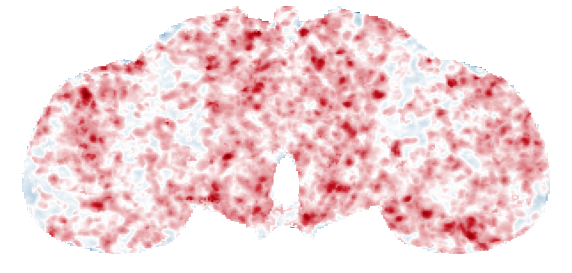

In [15]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]

color_map_color_2=np.asarray(['#5005AF','#9D69D4','#CCB2E7','#FBFAFA','#F6C0DC','#F186BE', '#DB0066' ])

color_map_color_3=np.asarray(['#054A29','#6BAB90','#B5D5C8','#FFFFFF','#E4C5DC','#C98BB9', '#7D5BA6' ])

color_map_color_4=np.asarray(['#1F2041','#4B3F72','#A59FB9','#D2CFDC','#FFFFFF','#C4E7E9','#88CED2','#119DA4', '#19647E' ])

total_colors=color_map_color_3

cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

# cmap=matplotlib.colors.ListedColormap(total_colors)
fig, axs = plt.subplots(figsize=(10,10))
# img=axs.imshow(np.nanmean(np.nanmax(masked[25:30,...], axis=-1), axis=0).T, cmap='Spectral')
img=axs.imshow(np.nanmax(masked[...,3], axis=-1).T, cmap=cmap_personal)
axs.axis('off');
# fig.colorbar(img, ax=axs)
# plt.savefig(os.path.join(save_dir,'STA.png'), dpi=300, bbox_inches='tight')

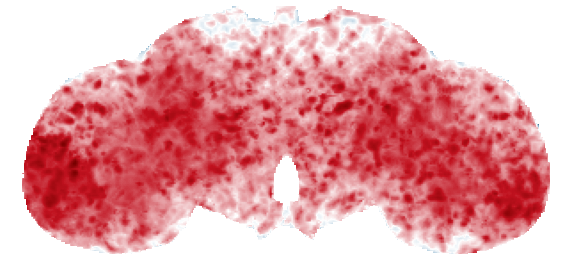

In [16]:
fig, axs = plt.subplots(figsize=(10,10))
# axs.imshow(np.nanmean(np.nanmax(masked[70:85,...], axis=-1), axis=0).T, cmap='Spectral_r')
img=axs.imshow(np.nanmax(masked[...,16], axis=-1).T, cmap=cmap_personal)
axs.axis('off');
# fig.colorbar(img, ax=axs)

In [17]:
vox_traces=masked
# vox_traces_pre=masked[25]
# vox_traces_post=masked[75]
vox_traces_pre=masked[...,3]
vox_traces_post=masked[...,16]
print(vox_traces.shape)
# z,xy,t=vox_traces.shape
# t,x,y,z=vox_traces.shape
x,y,z,t=vox_traces.shape
flattened=vox_traces.reshape(x*y*z*t)
flattened_pre=vox_traces_pre.reshape(x*y*z)
flattened_pre=flattened_pre[~np.isnan(flattened_pre)]
flattened_post=vox_traces_post.reshape(x*y*z)
flattened_post=flattened_post[~np.isnan(flattened_post)]
print(flattened.shape)

(314, 146, 91, 24)
(100123296,)


In [18]:
def mean_edges(flattened):
    mean_line=np.nanmean(flattened)
    std=np.nanstd(flattened)
    neg_edge=mean_line-std
    pos_edge=mean_line+std
    return mean_line, neg_edge, pos_edge

In [19]:
m,n,p=mean_edges(flattened)
mr,nr,pr=mean_edges(flattened_pre)
mo,no,po=mean_edges(flattened_post)

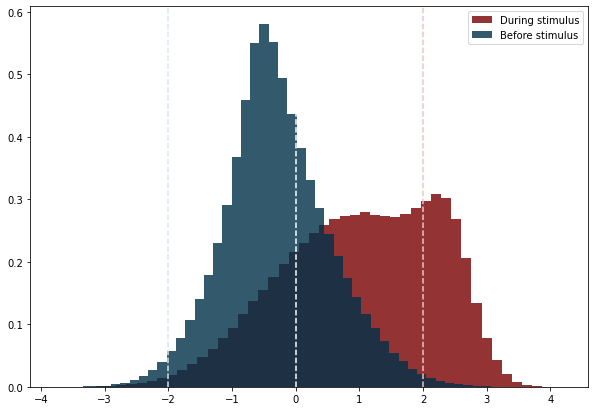

In [20]:
n_bins=100
fig, ax=plt.subplots(figsize=(10,7));
# plt.hist(flattened, bins=n_bins, density=True, color='k', label="Total");
ax.hist(flattened_post, bins=int(n_bins/2), density=True,color='#780000', alpha=0.8, label="During stimulus");
ax.hist(flattened_pre, bins=int(n_bins/2), density=True, color='#003049', alpha=0.8, label="Before stimulus");


ax.axvline(m, ls='--', color='w')
ax.axvline(n*2, ls='--', color='#D9E6EF')
ax.axvline(p*2, ls='--', color='#F0C4C7')
# ax.set_xlim((-0.1,0.2))
ax.legend();
# plt.savefig(os.path.join(save_dir,'supervox_hist.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'supervox_hist.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [21]:
hist_b, edges_b=np.histogram(flattened_pre, bins=int(n_bins/2), density=True)
hist_d, edges_d=np.histogram(flattened_post, bins=int(n_bins/2), density=True)

In [22]:
edges_d.max()

4.1953673

In [23]:
b=norm.cdf(hist_b, edges_b[:-1])
d=norm.cdf(hist_d, edges_d[:-1])
print(np.shape(b))

(50,)


In [24]:
Xb=flattened_pre.reshape(-1,1)
Xd=flattened_post.reshape(-1,1)
valb, edgesb=np.histogram(Xb)
vald, edgesd=np.histogram(Xd)
all_edges=[edgesb.max(), edgesb.min(), edgesd.max(), edgesd.min()]
total_max=np.max(all_edges)
total_min=np.min(all_edges)
x = np.linspace(total_min, total_max, 1000)

In [25]:
def make_cdf(X, x, comps):
    # estimate probability density function (pdf)
    model = GaussianMixture(n_components=comps)
    model.fit(X)
    logprob = model.score_samples(x.reshape(-1, 1))
    pdf = np.exp(logprob)
    # derive cumulative distribution function (cdf)
    cdf = np.cumsum(pdf)
    # scale as a probability distribution
    cdf = cdf / np.max(cdf)
    return cdf,pdf

In [26]:
cdfb, pdfb=make_cdf(Xb, x, 5)
cdfd, pdfd=make_cdf(Xd, x, 5)

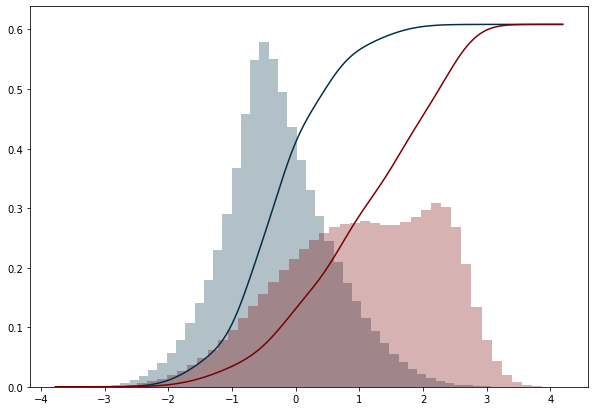

In [27]:
# plot data and pdf  
plt.subplots(figsize=(10,7));
plt.hist(Xb, 50, density=True,color='#003049', histtype='stepfilled', alpha=0.3)
plt.hist(Xd, 50, density=True,color='#780000', histtype='stepfilled', alpha=0.3)
# plt.plot(x, pdfb, '-k', alpha=0.3)
# plt.plot(x, pdfd, '-k', alpha=0.3)
# plot cdf, scaled to the y limits of the above plot
xmin, xmax, ymin, ymax = plt.axis()
plt.plot(x, cdfb * ymax, color='#003049', label="Before stimulus");
plt.plot(x, cdfd * ymax, color='#780000', label="During stimulus");
# plt.savefig(os.path.join(save_dir,'supervox_hist.png'), dpi=300, bbox_inches='tight')
# plt.legend();

In [28]:
# KS = scipy.stats.ks_2samp(flattened_post, flattened_pre)
# MW = scipy.stats.mannwhitneyu(flattened_post, flattened_pre)
TT = scipy.stats.ttest_ind(flattened_post, flattened_pre)
WC = scipy.stats.wilcoxon(flattened_post, flattened_pre, alternative='two-sided')


In [30]:
# print(KS)
# print(MW)
print(TT)
print(WC)

Ttest_indResult(statistic=1138.3185452040668, pvalue=0.0)
WilcoxonResult(statistic=154871580253.5, pvalue=0.0)


In [29]:
imgs = axs.get_images()
if len(imgs) > 0:
    vmin, vmax = imgs[0].get_clim()

In [30]:
vmax

5.798253

In [31]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape

(1256, 584, 363)

In [32]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')

(1256, 584, 363)


In [33]:
%%time
# brain_pre=np.mean(full_res['total'][25:35,...], axis=0)
# brain_pre=full_res['total'][25,...]
# brain_pre=behave_dict['total'][...,2]
brain_pre=behave_dict_z['total'][...,17]
# brain_pre=np.nan_to_num(full_res_total_clean[...,2])
# brain_post=np.mean(full_res['total'][70:85,...], axis=0)
# brain_post=full_res['total'][75,...]
brain_post=behave_dict_z['total'][...,25]
# brain_post=np.nan_to_num(full_res_total_clean[...,15])
# brain_post=behave_dict['total'][...,25]
# plt.imshow(brain_pre[...,10])
# Calculate the scaling factors
nx,ny,nz=atlas.shape
ox,oy,oz=brain_pre.shape
scale_factors = (nx/ox, ny/oy, nz/oz)
# Resample using zoom with cubic interpolation (order=3)
maps_voxel_high_res_pre = zoom(brain_pre, scale_factors, order=3)
maps_voxel_high_res_post = zoom(brain_post, scale_factors, order=3)

CPU times: user 2min 2s, sys: 1.06 s, total: 2min 3s
Wall time: 2min 3s


In [34]:
maps_voxel_high_res_post.shape

(1256, 584, 363)

In [35]:
no, nr, pr, po

(0.16892457, -0.978912, 0.7620399, 3.5778701)

In [36]:
masked_pre=np.where(anat_high_res>0.1,maps_voxel_high_res_pre, np.nan)
masked_post=np.where(anat_high_res>0.1,maps_voxel_high_res_post, np.nan)

total_masked_pre_max=np.where(masked_pre>(p*2),masked_pre, np.nan)
total_masked_pre_min=np.where(masked_pre<(n*2),masked_pre, np.nan)
total_masked_post_max=np.where(masked_post>(p*2),masked_post, np.nan)
total_masked_post_min=np.where(masked_post<(n*2),masked_post, np.nan)

In [37]:
# Extract the top half of plasma_r colors
# spect_cmap = plt.cm.Spectral
# spect_cmap_r = plt.cm.Spectral_r
# top_half_colors = spect_cmap(np.linspace(0.5, 0.0, 256))  # Only use 0-0.5 range
# bottom_half_colors = spect_cmap_r(np.linspace(0.0, 0.5, 256)) 
# # Create a new colormap
# top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'top_half_spect', top_half_colors)
# bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'bottom_half_spect', bottom_half_colors)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)


# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

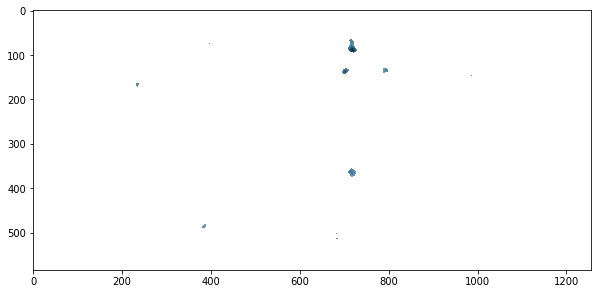

In [38]:
plt.figure(figsize=(10,10))
plt.imshow(total_masked_pre_min[...,200].T, vmax=0.05, cmap='bottom_half_spect')
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(final)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


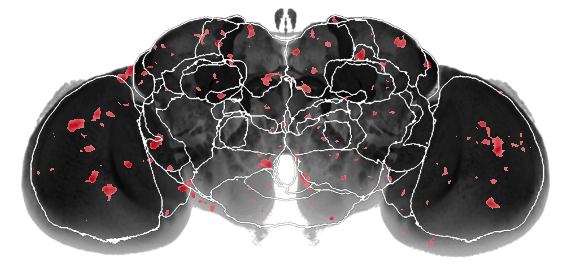

In [39]:
z=250
edges = cv2.Canny(np.max(atlas_int,axis=-1),1,1)
edges = binary_dilation(edges, iterations=1)
edges = scipy.ndimage.median_filter(edges,2)
edges_ = np.repeat(edges.astype('int')[:,:,np.newaxis],repeats=4,axis=-1) ### copy into rgba channels to make white
plt.figure(figsize=(10,10))
plt.imshow(np.max(anat_high_res, axis=-1).T,cmap='gray_r');
plt.imshow(np.nanmax(total_masked_post_max, axis=-1).T,vmax=5, vmin=1,cmap='top_half_spect');
# plt.imshow(np.nanmin(total_masked_pre_min, axis=-1).T,cmap='bottom_half_spect');
plt.imshow(np.swapaxes(edges_,0,1)*10000);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'total_overlay_15_min.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'total_overlay_t4.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [40]:
p

1.1770141

In [41]:
np.nanmax(total_masked_post_max)

4.3435273

In [42]:
max_count=np.count_nonzero(~np.isnan(total_masked_pre_max))
total_count=np.count_nonzero(~np.isnan(masked_post))
percent=(max_count/total_count)*100

In [43]:
percent

33.149635615707275

In [44]:
red_vals=np.where(masked_pre>p,masked_pre, np.nan)
red_count=np.count_nonzero(~np.isnan(red_vals))
total_count=np.count_nonzero(~np.isnan(masked_post))
percent_red=(red_count/total_count)*100

In [45]:
percent_red

55.667459272434904

In [46]:
roi_atlas = brainsss.load_roi_atlas()

In [47]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [48]:
def extract_roi_signal_traces(roi_ids, roi_masks, warps, hemi, signal_type):
    t0 = time.time()
    roi_time_avgs = []
    for roi in roi_ids[hemi]:
        mask = roi_masks[roi]
        masked_data = warps[:,:,:,:]*mask[np.newaxis,:,:,:] #note z-flip
        if signal_type == 'max':
            roi_time_avg = np.max(masked_data,axis=(1,2,3))
        elif signal_type == 'mean':
            roi_time_avg = np.mean(masked_data,axis=(1,2,3))
        roi_time_avgs.append(roi_time_avg)
    print(time.time()-t0)
    return np.asarray(roi_time_avgs)

In [49]:
# %%time
# brain=full_res['total']
# t=np.shape(brain)[0]
# explosions = []
# for tp in range(t):
#     input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
#     data_to_plot = brain[tp][:,:,::-1]
#     vmax = 0.08 #this was 0.5 for STA <------------
#     explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
#                                                         roi_masks,
#                                                         roi_contours,
#                                                         data_to_plot,
#                                                         input_canvas,
#                                                         vmax=vmax,
#                                                         cmap='PuOr', diverging=True)#'hot')
#     explosions.append(explosion_map)

In [50]:
behave_dict_z['total'].shape

(314, 146, 91, 27)

10
11
12
13
14
15
16
17
18
19
20
21
22
23


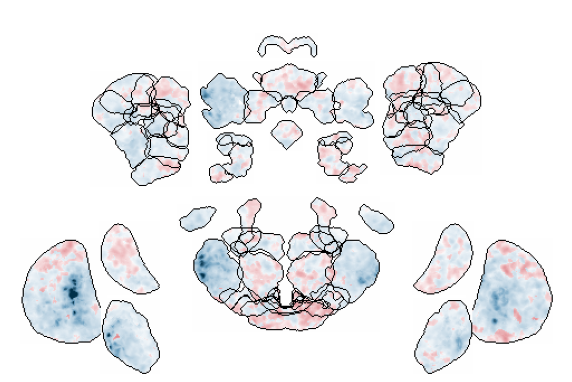

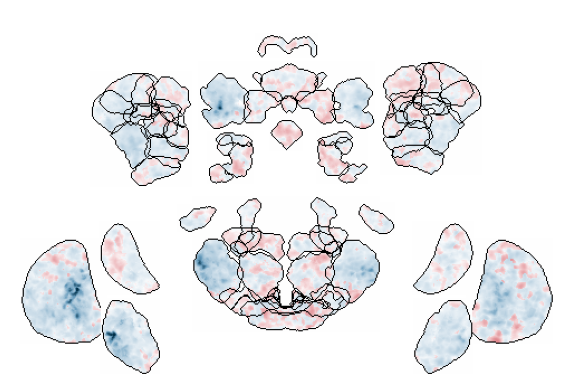

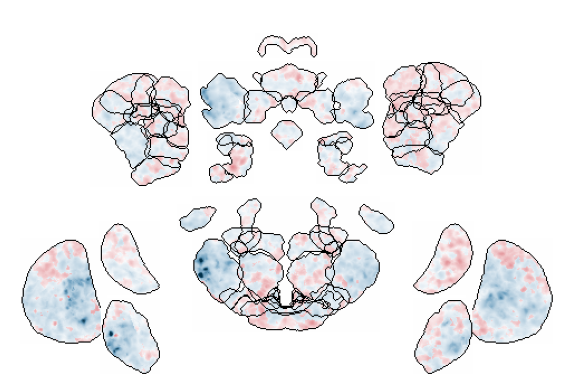

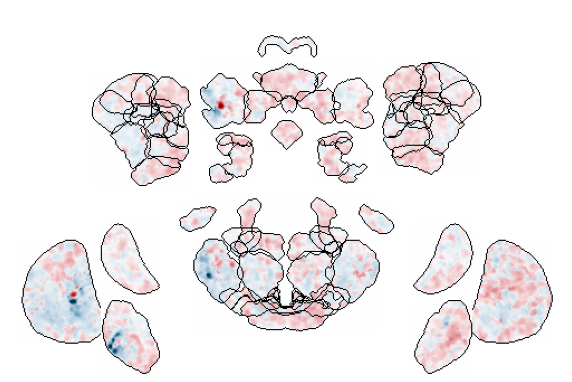

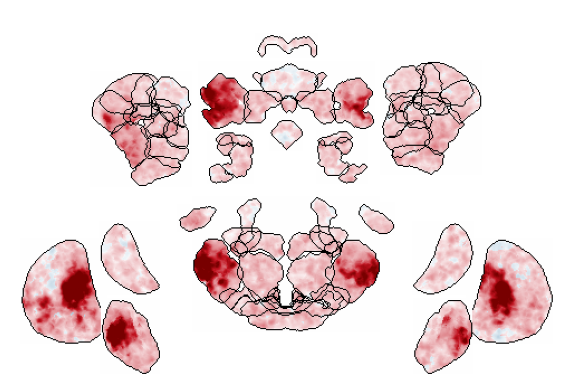

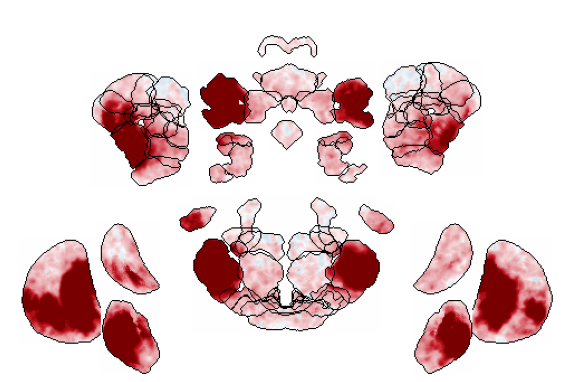

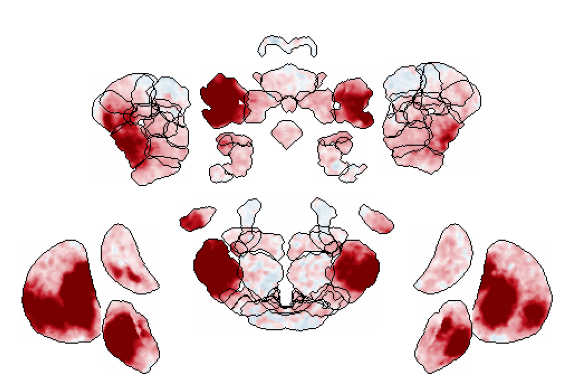

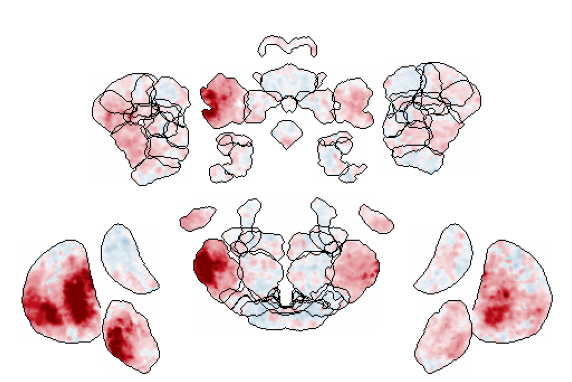

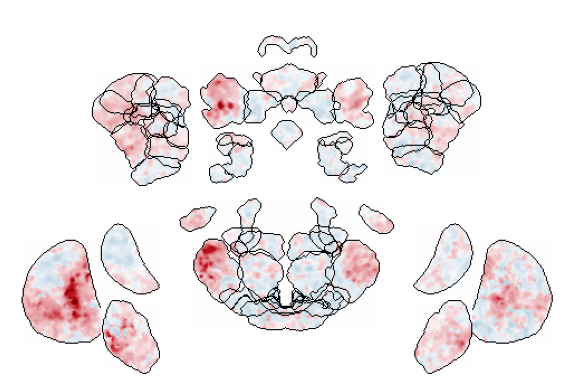

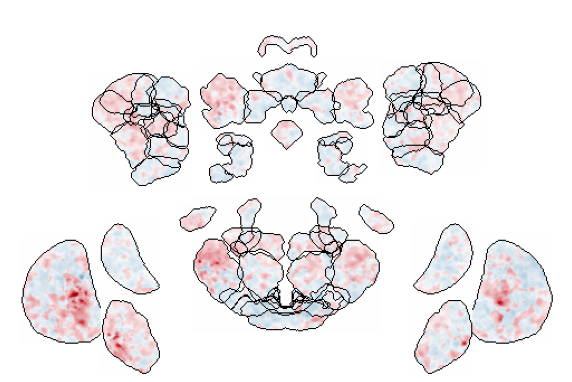

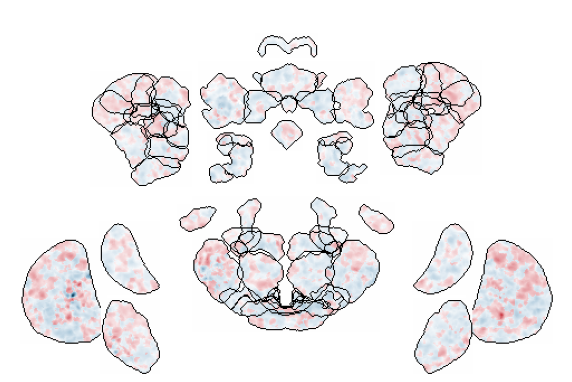

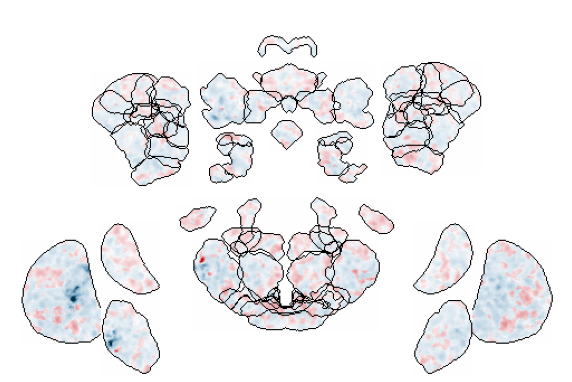

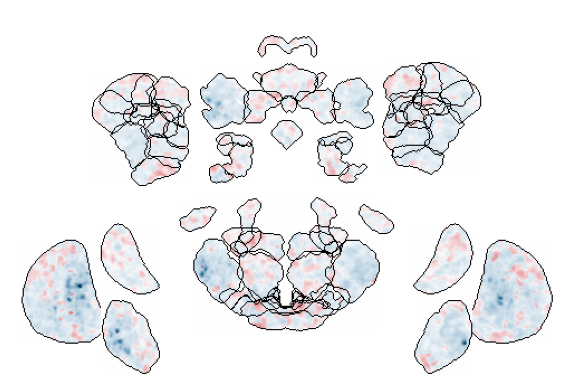

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.


In [70]:
save_dir=os.path.join(later_dir,'figs')
brain=np.moveaxis(behave_dict['total'],-1,0)
# brain=np.moveaxis(np.nan_to_num(full_res_total_clean),-1,0)
for i in range(np.shape(brain)[0]):
    tp=i
    print(i)
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    data_to_plot = brain[tp][:,:,::-1]
    vmax = 5 #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap_personal, diverging=True)#'hot')
    plt.subplots(figsize=(10,10))
    plt.imshow(explosion_map[170:,:])
    plt.axis('off')
#     plt.savefig(os.path.join(save_dir,f'explode_{tp}.png'), dpi=300, bbox_inches='tight')

(-0.5, 499.5, 329.5, -0.5)

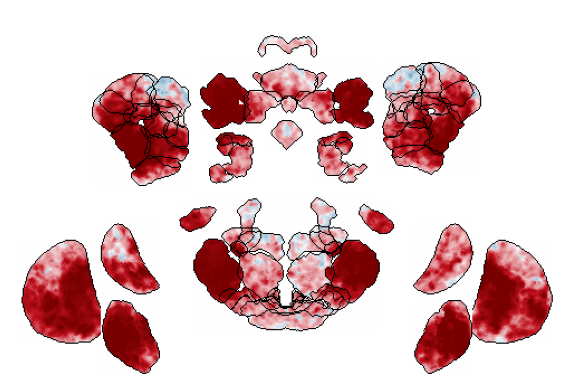

In [52]:
save_dir=os.path.join(later_dir,'figs')
plt.subplots(figsize=(10,10))
# plt.imshow(explosions[40][170:,:]) #this was made with cmap=hot
plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')
# plt.savefig(os.path.join(save_dir,'explode_15.png'), dpi=300, bbox_inches='tight')

In [51]:
%%time

total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
#             print(np.shape(STA))
            masked_roi=[STA[...,i][roi_mask] for i in range(np.shape(STA)[-1])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi

CPU times: user 9.35 s, sys: 310 ms, total: 9.66 s
Wall time: 9.66 s


In [52]:
vis=['PVLP', 'AVLP', 'AOTU', 'MED', 'LO', 'LP']
anat_avgs_vis={}
anat_avgs_novis={}
for behavior in total_vox_sorted:
    bbrain=total_vox_sorted[behavior]
    anat_avgs_vis[behavior]={}
    anat_avgs_novis[behavior]={}
    for anat in bbrain:
        n,t=np.shape(bbrain[anat])
        if anat in vis:
            anat_avgs_vis[behavior][anat] = gaussian_filter1d(np.mean(bbrain[anat], axis=0), sigma=1)
        else:
            anat_avgs_novis[behavior][anat] = gaussian_filter1d(np.mean(bbrain[anat], axis=0), sigma=1)#/(np.std(bbrain[anat], axis=0)/np.sqrt(n))

In [72]:
np.shape(list(anat_avgs_vis['total'].values()))

(6, 27)

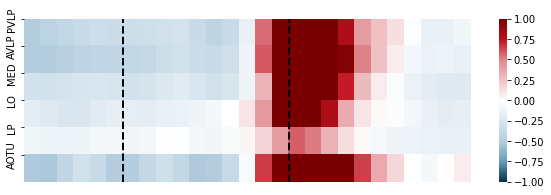

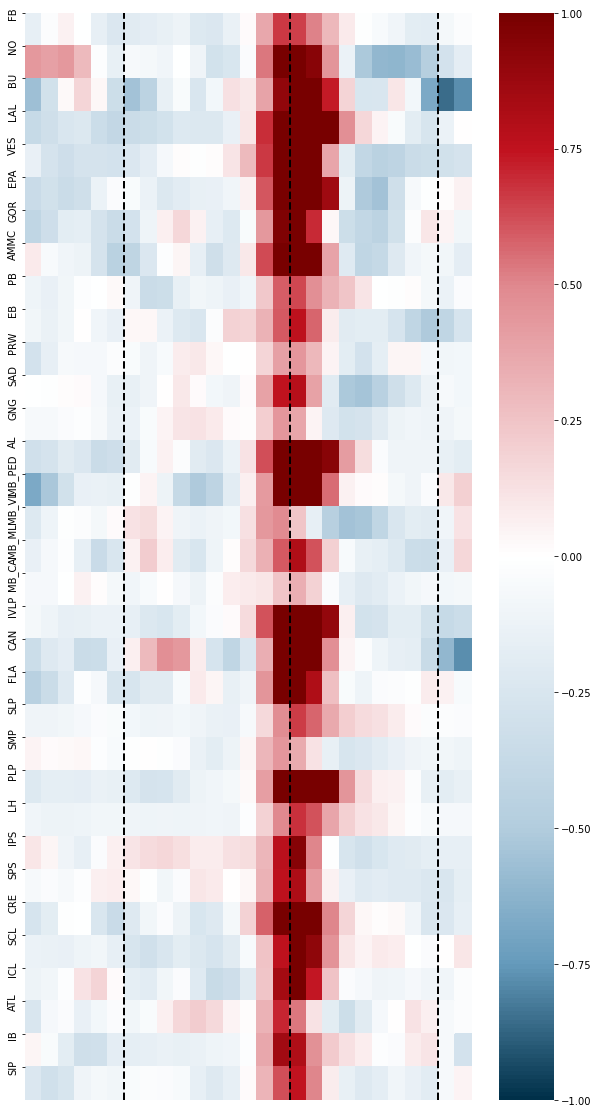

In [73]:
avg_behave=anat_avgs_vis['total']
vmax=1
vmin=-1
fig,axs = plt.subplots(figsize=(10,3))
avg=sns.heatmap(list(avg_behave.values()), vmax=vmax, vmin=vmin, cmap=cmap_personal)
axs.axvline(x=6, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=16, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.set_yticks(np.arange(len(list(avg_behave.keys()))))
axs.set_yticklabels(list(avg_behave.keys()))
axs.set_xticks([])

# fig.colorbar(avg)

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
        
plt.show()

avg_behave=anat_avgs_novis['total']
vmax=1
vmin=-1
fig,axs = plt.subplots(figsize=(10,20))
avg=sns.heatmap(list(avg_behave.values()), vmax=vmax, vmin=vmin, cmap=cmap_personal)
axs.axvline(x=6, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=16, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.set_yticks(np.arange(len(list(avg_behave.keys()))))
axs.set_yticklabels(list(avg_behave.keys()))
axs.axvline(x=25, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.set_xticks([])

# fig.colorbar(avg)

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
        
plt.show()